## QRS area vs age

* Before running this notebook, download all the data files from zenodo
* Run the script `scripts/one_beat.py` before running this notebook

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DATA_DIR = "../data"

In [2]:
summary_area = []
for n in range(1, 17):
    df_summary = pd.read_csv(
        f"{DATA_DIR}/peak_summary_{n}.csv",
        usecols=['subject', 'exam_id', 'hr', 'retain_subject'],
    )
    df_summary = df_summary[df_summary['retain_subject']].reset_index(drop=True)
    df_summary = df_summary.groupby('subject')[['exam_id', 'hr']].first().reset_index()
    data_array = np.load(f"{DATA_DIR}/one_beat_array_{n}.npy")

    start = 2040
    end = 2060
    channel = [x for x in range(12)]
    replace_areas = []

    for i in range(len(data_array)):
        area = []
        for chan in channel:
            arange_start = float(data_array[i, start, chan])
            arange_end = float(data_array[i, end - 1,  chan])
            try:
                replace_val = np.linspace(arange_start, arange_end, (end - start))
            except ZeroDivisionError:
                # some subjects have faster heartbeats; so there will be zero padding
                replace_val = 0
            area.append(float(np.sum(np.abs(data_array[i, start:end, chan] - replace_val))))
        replace_areas.append(area)
    replace_areas = pd.DataFrame(replace_areas, columns=[f'chan_{x}' for x in range(12)])

    df_summary = df_summary.merge(
        replace_areas,
        left_on=df_summary.index,
        right_on=replace_areas.index,
    ).drop(columns=['key_0'])
    summary_area.append(df_summary)

In [3]:
df_meta = pd.read_csv(
    f"{DATA_DIR}/exams.csv",
    usecols=['exam_id', 'age', 'is_male', 'nn_predicted_age', 'normal_ecg']
)
df_summary = pd.concat(summary_area, axis=0).reset_index(drop=True)
df = df_summary.merge(
    df_meta,
    on='exam_id'
)
df.shape

(90618, 19)

In [8]:
df.head()

,subject,exam_id,hr,chan_0,chan_1,chan_2,chan_3,chan_4,chan_5,chan_6,chan_7,chan_8,chan_9,chan_10,chan_11,age,is_male,nn_predicted_age,normal_ecg
0,0,4409337,101.553719,14.664838,14.980209,4.515231,14.331297,8.280983,8.935463,13.314684,15.284183,18.969527,19.822608,18.741575,13.618970,70,False,94.596580,False
1,1,835969,72.444741,9.173110,19.237566,10.078439,14.199765,2.302571,14.666255,4.842344,6.239963,16.889898,24.650970,26.082224,23.692305,63,True,61.776833,True
2,12,2668899,75.553887,8.505629,18.437261,10.259320,13.383575,1.715569,14.298545,17.464900,24.456217,24.715502,19.555759,30.152224,27.673257,47,False,46.891685,False
3,13,884099,64.699482,15.530058,20.201122,15.923738,16.622940,12.758189,15.941051,18.516588,20.603591,14.172960,20.820640,22.284384,18.963030,37,False,69.076965,False
4,14,526403,93.929999,17.626192,7.356739,12.494787,12.020889,14.985608,5.262685,9.463708,12.551148,17.954583,18.971573,14.329731,10.213150,43,False,41.630150,True


In [ ]:
column = [
    'subject',
    'exam_id',
    'hr',
    'age',
    'is_male',
    'nn_predicted_age',
    'normal_ecg',
    'channel',
    'area'
]

In [1]:
plt.scatter(
    df['age'],
    df['chan_0'],
    marker='.',
)
plt.title("All Subject with Certain Filters")
plt.xlabel("Age")
plt.ylabel("Area Replaced Chan 0 (mV)")
plt.show()

NameError: name 'plt' is not defined

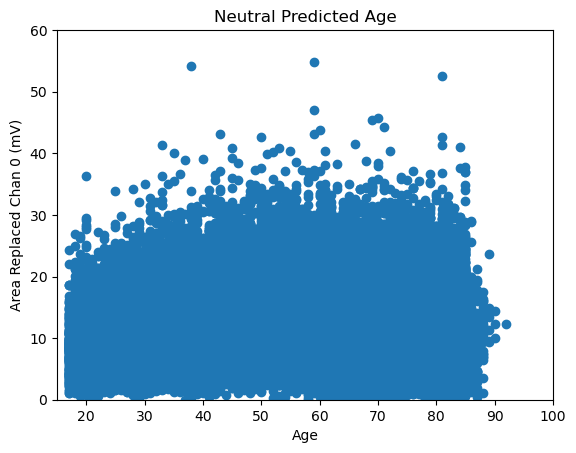

In [10]:
neutral_age_filter = abs(df['age'] - df['nn_predicted_age']) < 8

plt.scatter(
    df[neutral_age_filter]['age'],
    df[neutral_age_filter]['chan_0']
)
plt.xlim(15, 100)
plt.ylim(0, 60)
plt.title("Neutral Predicted Age")
plt.xlabel("Age")
plt.ylabel("Area Replaced Chan 0 (mV)")
plt.show()

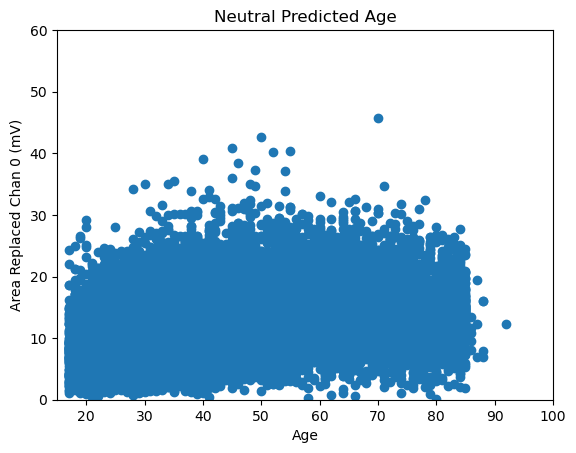

In [11]:
neutral_age_filter = abs(df['age'] - df['nn_predicted_age']) < 8
normal_ecg = df['normal_ecg']
old_ecg = df['nn_predicted_age'] - df['age'] >= 8
young_ecg = df['age'] - df['nn_predicted_age'] >= 8

plt.scatter(
    df[(neutral_age_filter) & (normal_ecg)]['age'],
    df[(neutral_age_filter) & (normal_ecg)]['chan_0']
)
plt.xlim(15, 100)
plt.ylim(0, 60)
plt.title("Neutral Predicted Age")
plt.xlabel("Age")
plt.ylabel("Area Replaced Chan 0 (mV)")
plt.show()

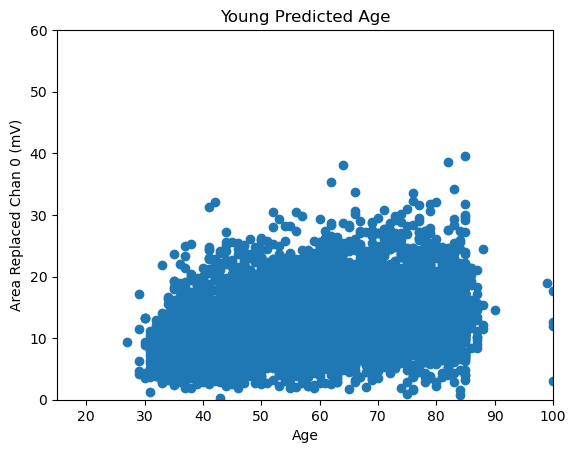

In [12]:
plt.scatter(
    df[(young_ecg) & (normal_ecg)]['age'],
    df[(young_ecg) & (normal_ecg)]['chan_0']
)
plt.xlim(15, 100)
plt.ylim(0, 60)
plt.title("Young Predicted Age")
plt.xlabel("Age")
plt.ylabel("Area Replaced Chan 0 (mV)")
plt.show()

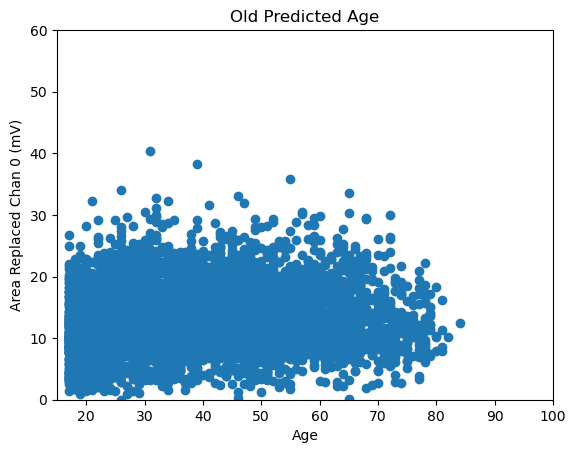

In [13]:
plt.scatter(
    df[(old_ecg) & (normal_ecg)]['age'],
    df[(old_ecg) & (normal_ecg)]['chan_0']
)
plt.xlim(15, 100)
plt.ylim(0, 60)
plt.title("Old Predicted Age")
plt.xlabel("Age")
plt.ylabel("Area Replaced Chan 0 (mV)")
plt.show()

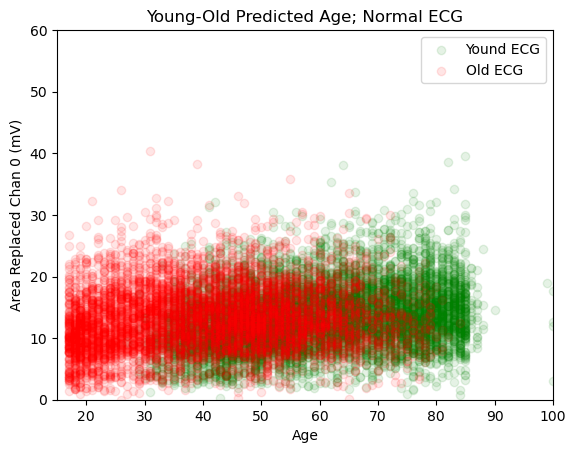

In [14]:
plt.scatter(
    df[(young_ecg) & (normal_ecg)]['age'],
    df[(young_ecg) & (normal_ecg)]['chan_0'],
    alpha=0.1,
    c='g',
    label='Yound ECG'
)
plt.scatter(
    df[(old_ecg) & (normal_ecg)]['age'],
    df[(old_ecg) & (normal_ecg)]['chan_0'],
    alpha=0.1,
    c='r',
    label='Old ECG'
)
plt.xlim(15, 100)
plt.ylim(0, 60)
plt.title("Young-Old Predicted Age; Normal ECG")
plt.xlabel("Age")
plt.ylabel("Area Replaced Chan 0 (mV)")
plt.legend()
plt.show()

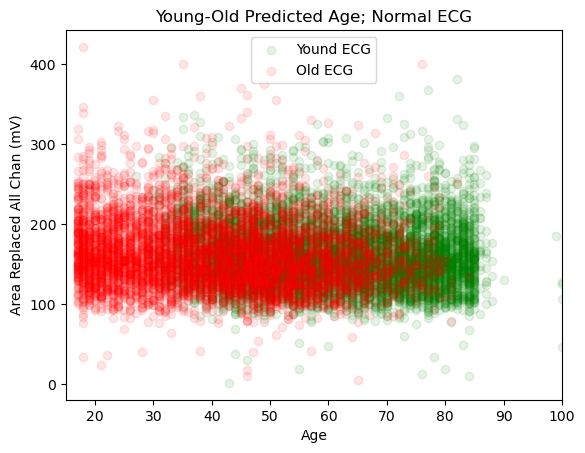

In [15]:
channel_cols = [col for col in df.columns if 'chan_' in col]
df.loc[:, "all_chan_area"] = df[channel_cols].sum(axis=1)

plt.scatter(
    df[(young_ecg) & (normal_ecg)]['age'],
    df[(young_ecg) & (normal_ecg)]['all_chan_area'],
    alpha=0.1,
    c='g',
    label='Yound ECG'
)
plt.scatter(
    df[(old_ecg) & (normal_ecg)]['age'],
    df[(old_ecg) & (normal_ecg)]['all_chan_area'],
    alpha=0.1,
    c='r',
    label='Old ECG'
)
plt.xlim(15, 100)
# plt.ylim(0, 60)
plt.title("Young-Old Predicted Age; Normal ECG")
plt.xlabel("Age")
plt.ylabel("Area Replaced All Chan (mV)")
plt.legend()
plt.show()

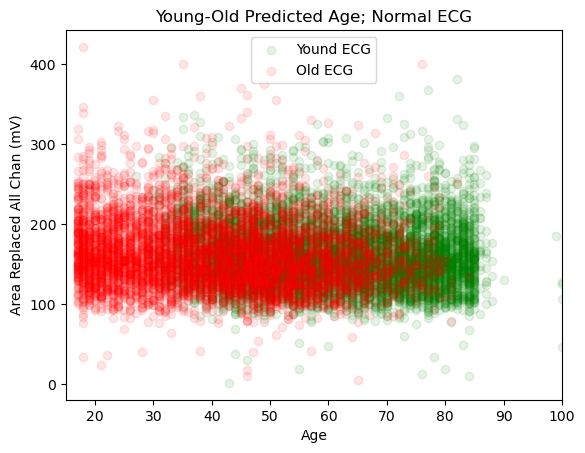

In [16]:

plt.scatter(
    df[(young_ecg) & (normal_ecg)]['age'],
    df[(young_ecg) & (normal_ecg)]['all_chan_area'],
    alpha=0.1,
    c='g',
    label='Yound ECG'
)
plt.scatter(
    df[(old_ecg) & (normal_ecg)]['age'],
    df[(old_ecg) & (normal_ecg)]['all_chan_area'],
    alpha=0.1,
    c='r',
    label='Old ECG'
)
plt.xlim(15, 100)
# plt.ylim(0, 60)
plt.title("Young-Old Predicted Age; Normal ECG")
plt.xlabel("Age")
plt.ylabel("Area Replaced All Chan (mV)")
plt.legend()
plt.show()

In [17]:
df[young_ecg]

,subject,exam_id,hr,chan_0,chan_1,chan_2,chan_3,chan_4,chan_5,chan_6,chan_7,chan_8,chan_9,chan_10,chan_11,age,is_male,nn_predicted_age,normal_ecg,all_chan_area
5,21,1372286,75.886987,30.476032,43.700702,13.319712,37.094914,8.850783,28.508153,62.371618,56.087069,12.153071,37.021615,67.174577,65.424179,66,True,41.870860,False,462.182425
7,26,1218810,59.588885,11.368839,16.484656,5.121606,13.898883,3.146464,10.808148,18.554406,11.468180,19.288257,20.668731,18.506449,15.934606,68,False,57.903850,False,165.249226
9,31,313640,71.395741,11.754649,9.761049,2.884874,10.591218,7.320731,4.328934,16.024390,10.375240,20.020606,39.172994,23.804492,19.953506,68,True,57.314003,True,175.992684
12,43,3796543,67.643915,14.029856,12.341834,5.657808,12.916352,8.275312,7.172953,19.898412,12.510307,10.715243,35.914863,33.816132,25.124626,76,True,63.893837,False,198.373697
14,55,3012859,69.213990,14.041209,18.929667,4.888457,16.505674,4.741518,11.893042,12.738172,5.871411,10.453392,23.457140,18.250790,12.890016,63,False,42.927345,False,154.660487
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
90607,19965,2106776,53.280150,10.912532,8.606187,19.518718,1.672382,15.215361,14.060149,1.539798,14.931390,1.721258,1.161048,1.426489,5.549091,88,False,75.641480,False,96.314403
90611,19977,1908376,66.873472,11.262318,10.309159,3.128100,10.660314,6.292826,5.575284,16.171277,12.697337,30.697843,5.052327,29.782079,16.697621,43,False,29.743658,True,158.326486
90612,19978,1880339,105.940262,8.115571,6.693825,6.724575,6.522616,7.314171,4.909312,8.117489,8.809947,18.013974,24.968224,22.324443,11.172809,71,True,54.793785,False,133.686957
90613,19979,1888929,53.190969,8.093128,22.115614,14.047398,15.078050,3.866814,18.095472,20.724450,27.224694,28.662576,40.960422,36.913809,28.731669,80,True,69.471490,True,264.514098


In [18]:
df.loc[:, 'classification'] = "Neutral"
df.loc[young_ecg, 'classification'] = 'Young'
df.loc[old_ecg, 'classification'] = 'Old'

In [19]:
df_grp = df.groupby(
    ['age', 'classification', 'normal_ecg', 'is_male']
)['all_chan_area'].mean().reset_index()

df_class = df.groupby(
    ['age', 'classification']
).agg(
    area_mean=('all_chan_area', np.mean),
    area_std=('all_chan_area', np.std)
).reset_index()

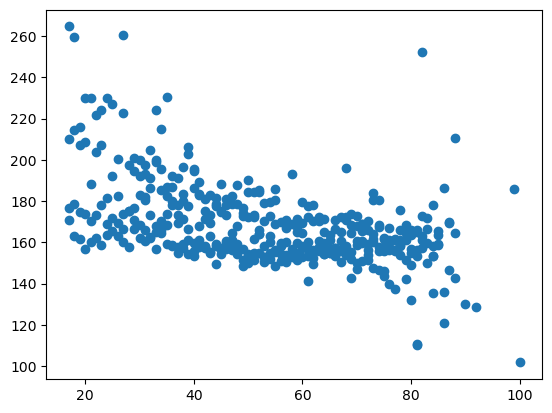

In [20]:
plt.scatter(
    df_grp[df_grp['normal_ecg']]['age'],
    df_grp[df_grp['normal_ecg']]['all_chan_area'],
)

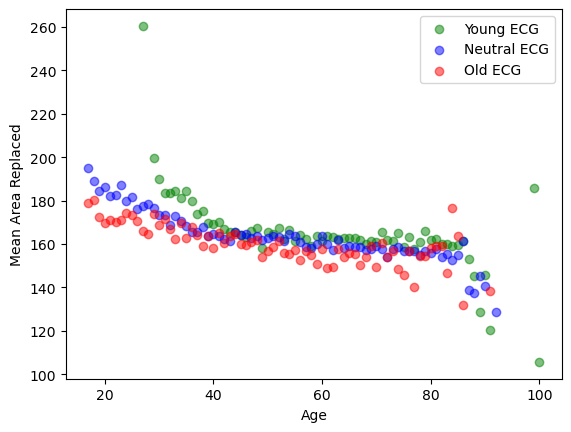

In [21]:
# scatter plot age vs area for each group, classification, normal_ecg, is_male

young_ecg = df_class['classification'] == 'Young'
old_ecg = df_class['classification'] == 'Old'
neutral_ecg = df_class['classification'] == 'Neutral'

plt.scatter(
    df_class[young_ecg]['age'],
    df_class[young_ecg]['area_mean'],
    c='g',
    alpha=0.5,
    label='Young ECG'
)

plt.scatter(
    df_class[neutral_ecg]['age'],
    df_class[neutral_ecg]['area_mean'],
    c='b',
    alpha=0.5,
    label='Neutral ECG'
)

plt.scatter(
    df_class[old_ecg]['age'],
    df_class[old_ecg]['area_mean'],
    c='r',
    alpha=0.5,
    label='Old ECG'
)
plt.xlabel('Age')
plt.ylabel('Mean Area Replaced')
plt.legend()
plt.show()

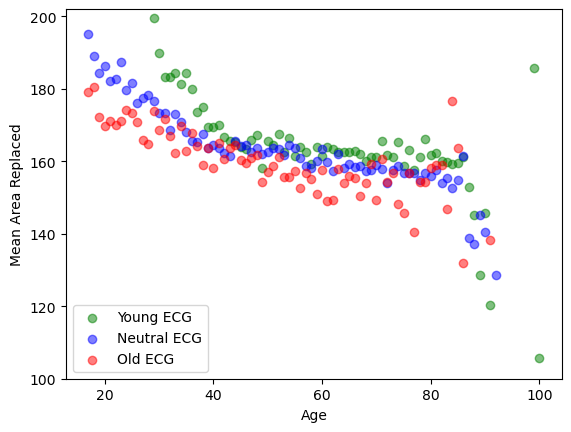

In [22]:
# scatter plot age vs area for each group, classification, normal_ecg, is_male

young_ecg = df_class['classification'] == 'Young'
old_ecg = df_class['classification'] == 'Old'
neutral_ecg = df_class['classification'] == 'Neutral'

plt.scatter(
    df_class[young_ecg]['age'],
    df_class[young_ecg]['area_mean'],
    c='g',
    alpha=0.5,
    label='Young ECG'
)

plt.scatter(
    df_class[neutral_ecg]['age'],
    df_class[neutral_ecg]['area_mean'],
    c='b',
    alpha=0.5,
    label='Neutral ECG'
)

plt.scatter(
    df_class[old_ecg]['age'],
    df_class[old_ecg]['area_mean'],
    c='r',
    alpha=0.5,
    label='Old ECG'
)
plt.ylim(100, 202)
plt.xlabel('Age')
plt.ylabel('Mean Area Replaced')
plt.legend()
plt.show()

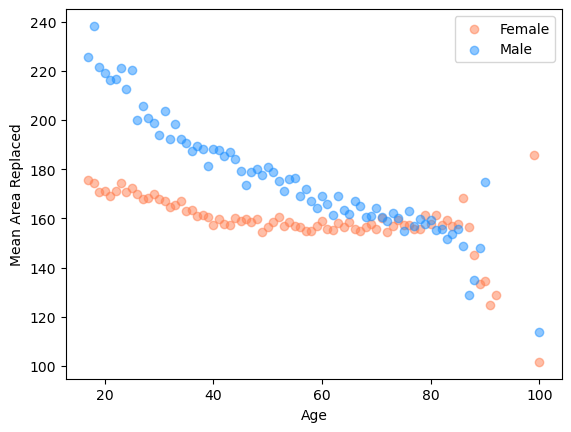

In [23]:
df_gender = df.groupby(
    ['age', 'is_male']
).agg(
    area_mean=('all_chan_area', np.mean),
    area_std=('all_chan_area', np.std)
).reset_index()

male_filt = df_gender['is_male']
plt.scatter(
    df_gender[~male_filt]['age'],
    df_gender[~male_filt]['area_mean'],
    c='coral',
    alpha=0.5,
    label='Female'
)

plt.scatter(
    df_gender[male_filt]['age'],
    df_gender[male_filt]['area_mean'],
    c='dodgerblue',
    alpha=0.5,
    label='Male'
)
plt.xlabel('Age')
plt.ylabel('Mean Area Replaced')
plt.legend()
plt.show()

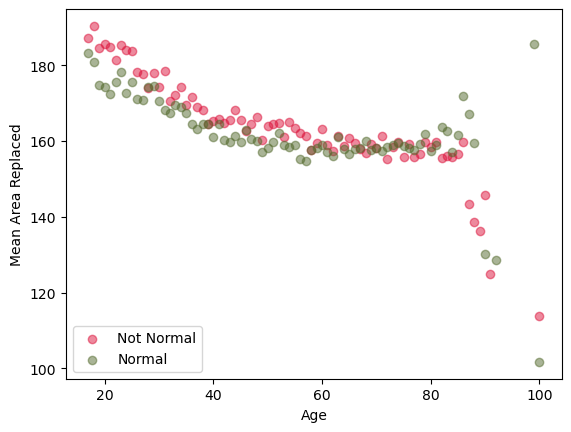

In [24]:
df_normal = df.groupby(
    ['age', 'normal_ecg']
).agg(
    area_mean=('all_chan_area', np.mean),
    area_std=('all_chan_area', np.std)
).reset_index()

normal_filt = df_normal['normal_ecg']
plt.scatter(
    df_normal[~normal_filt]['age'],
    df_normal[~normal_filt]['area_mean'],
    c='crimson',
    alpha=0.5,
    label='Not Normal'
)
plt.scatter(
    df_normal[normal_filt]['age'],
    df_normal[normal_filt]['area_mean'],
    c='darkolivegreen',
    alpha=0.5,
    label='Normal'
)
plt.xlabel('Age')
plt.ylabel('Mean Area Replaced')
plt.legend()
plt.show()

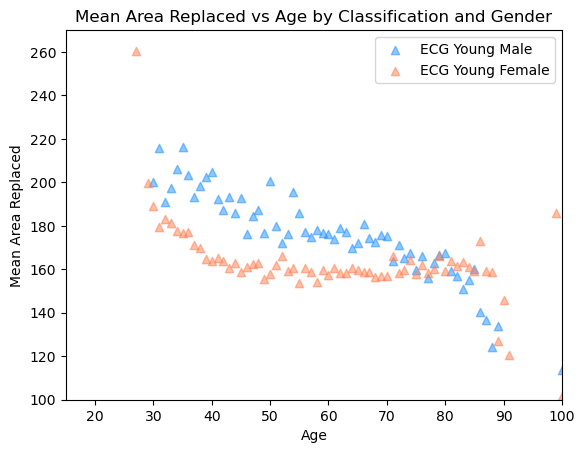

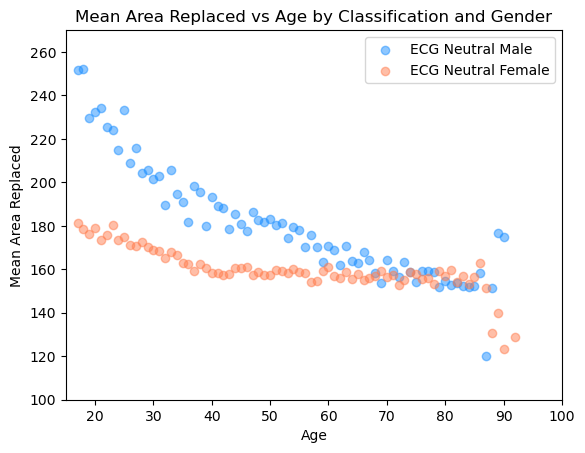

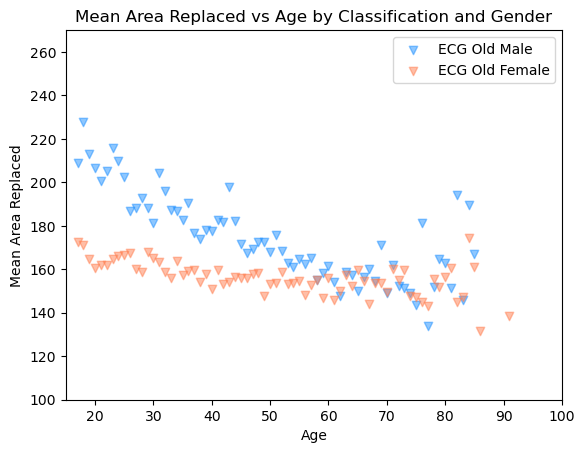

In [ ]:
df_gender_label = df.groupby(
    ['age', 'is_male', 'classification']
).agg(
    area_mean=('all_chan_area', np.mean),
    area_std=('all_chan_area', np.std)
).reset_index()

young_ecg = df_gender_label['classification'] == 'Young'
old_ecg = df_gender_label['classification'] == 'Old'
neutral_ecg = df_gender_label['classification'] == 'Neutral'

# scatter plot for age vs area for each classification
# plot males with dodgerblue and females with coral

male_filt = df_gender_label['is_male']
female_filt = ~male_filt

plt.scatter(
    df_gender_label[young_ecg & male_filt]['age'],
    df_gender_label[young_ecg & male_filt]['area_mean'],
    c='dodgerblue',
    alpha=0.5,
    marker='^',
    label='ECG Young Male'
)

plt.scatter(
    df_gender_label[young_ecg & female_filt]['age'],
    df_gender_label[young_ecg & female_filt]['area_mean'],
    c='coral',
    alpha=0.5,
    marker='^',
    label='ECG Young Female'
)
plt.xlim(15, 100)
plt.ylim(100, 270)
plt.legend()
plt.xlabel('Age')
plt.ylabel('Mean Area Replaced')
plt.title('Mean Area Replaced vs Age by Classification and Gender')
plt.show()

plt.scatter(
    df_gender_label[neutral_ecg & male_filt]['age'],
    df_gender_label[neutral_ecg & male_filt]['area_mean'],
    c='dodgerblue',
    alpha=0.5,
    marker='o',
    label='ECG Neutral Male'
)

plt.scatter(
    df_gender_label[neutral_ecg & female_filt]['age'],
    df_gender_label[neutral_ecg & female_filt]['area_mean'],
    c='coral',
    alpha=0.5,
    marker='o',
    label='ECG Neutral Female'
)
plt.xlim(15, 100)
plt.ylim(100, 270)
plt.legend()
plt.xlabel('Age')
plt.ylabel('Mean Area Replaced')
plt.title('Mean Area Replaced vs Age by Classification and Gender')
plt.show()

plt.scatter(
    df_gender_label[old_ecg & male_filt]['age'],
    df_gender_label[old_ecg & male_filt]['area_mean'],
    c='dodgerblue',
    alpha=0.5,
    marker='v',
    label='ECG Old Male'
)

plt.scatter(
    df_gender_label[old_ecg & female_filt]['age'],
    df_gender_label[old_ecg & female_filt]['area_mean'],
    c='coral',
    alpha=0.5,
    marker='v',
    label='ECG Old Female'
)

plt.xlim(15, 100)
plt.ylim(100, 270)
plt.legend()
plt.xlabel('Age')
plt.ylabel('Mean Area Replaced')
plt.title('Mean Area Replaced vs Age by Classification and Gender')
plt.show()